# ROP (Retinopathy of Prematurity) Multi-Task Classification

This notebook implements a multi-task deep learning model for ROP classification based on the multicenter study specifications.

## Tasks
- **Zone Classification**: 3 classes (Zone 1/2/3)
- **Stage Classification**: 4 classes (Stage 0/1/2/3)
- **Plus Classification**: 3 classes (normal/preplus/plus)
- **Aggressive ROP**: Binary (Yes/No)
- **Treatment Indication**: Binary (Yes/No)

## Model Architecture
- EfficientNet-B3/B4 or RetFound as backbone
- Multi-task heads for each classification task

## Data
- Images: `E:\Multicenter_ROP_study\Multicenter_images\selected_lens_images`
- Labels: `E:\Multicenter_ROP_study\multicenter_patient_data_20260103.xlsx`

In [ ]:
# ==================== Environment Setup ====================
import os
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import cv2
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR

# Torchvision
import torchvision.transforms as T
from torchvision import models

# timm for EfficientNet
import timm

# Metrics
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    cohen_kappa_score, accuracy_score
)

# Albumentations for augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# YAML for config saving
import yaml
from datetime import datetime

# Set seeds for reproducibility
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

In [ ]:
# ==================== Configuration ====================

class Config:
    """Training configuration - v3: Further overfitting reduction"""

    # Paths
    DATA_ROOT = Path(r"E:\Multicenter_ROP_study")
    IMAGE_DIR = DATA_ROOT / "Multicenter_images" / "selected_lens_images"
    EXCEL_PATH = DATA_ROOT / "multicenter_patient_data_20260103.xlsx"
    OUTPUT_DIR = Path(r"C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v3")  # v3 output

    # Model - Continue with lighter model
    MODEL_NAME = "efficientnet_b0"
    PRETRAINED = True
    DROPOUT = 0.5  # Keep high dropout

    # Image
    IMG_SIZE = 512

    # Training - Step 2: Stronger regularization
    BATCH_SIZE = 16
    NUM_WORKERS = 0  # Windows compatibility
    EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-3  # INCREASED from 1e-4 to 1e-3 (10x stronger L2 regularization)
    PATIENCE = 7  # REDUCED from 10 to 7 (earlier stopping)

    # Cross-validation
    N_FOLDS = 5

    # Task weights
    TASK_WEIGHTS = {
        'zone': 1.0,
        'stage': 1.0,
        'plus': 1.0,
        'aggressive_rop': 1.5,
        'treatment': 1.5
    }

    # Label smoothing (increased slightly)
    LABEL_SMOOTHING = 0.15  # INCREASED from 0.1 to 0.15

    # MixUp augmentation - NEW in v3
    MIXUP_ALPHA = 0.2  # NEW: MixUp for better generalization
    MIXUP_P = 0.5  # Apply MixUp with 50% probability

    # Augmentation parameters (same as v2, but with MixUp added)
    AUGMENTATION = {
        'rotation_limit': 180,
        'rotation_p': 0.9,
        'flip_h_p': 0.5,
        'flip_v_p': 0.5,
        'color_jitter_brightness': 0.2,
        'color_jitter_contrast': 0.2,
        'color_jitter_saturation': 0.2,
        'color_jitter_hue': 0.1,
        'color_jitter_p': 0.7,
        'clahe_clip_limit': 2.0,
        'clahe_p': 0.3,
        'blur_p': 0.4,
        'gaussian_noise_var_limit': (10.0, 50.0),
        'gaussian_noise_p': 0.3,
        'random_crop_scale': (0.85, 1.0),
        'random_crop_p': 0.4,
        'coarse_dropout_max_holes': 8,
        'coarse_dropout_p': 0.3,
        # NEW in v3
        'mixup_alpha': 0.2,
        'mixup_p': 0.5,
    }

    # Version info
    VERSION = "v3"
    DESCRIPTION = "Step 2 - Further overfitting reduction: increased weight_decay (10x), reduced patience, added MixUp, increased label smoothing"

config = Config()

## 1. Data Loading and Preprocessing

In [3]:
# ==================== Load Excel Data ====================

def load_patient_data(excel_path: Path) -> pd.DataFrame:
    """
    Load patient metadata from Excel file.
    
    Expected columns:
    - A: Video ID (identifier)
    - B: Facility
    - C: Sex
    - D: Gestational age (weeks)
    - E: Birth weight (g)
    - F: Corrected age (weeks)
    - G: Zone (1-3)
    - H: Stage (0-3)
    - I: Plus (normal/preplus/plus)
    - J: Aggressive ROP (Yes/No)
    - K: Act-ROP score (0-22)
    - L: Severity classification
    - M: Treatment indication (Yes/No)
    - N: Comments
    """
    df = pd.read_excel(excel_path)
    
    # Display column names for verification
    print("Columns in Excel file:")
    for i, col in enumerate(df.columns):
        print(f"  {i}: {col}")
    
    return df

# Load data
if config.EXCEL_PATH.exists():
    patient_df = load_patient_data(config.EXCEL_PATH)
    print(f"\nLoaded {len(patient_df)} records")
    display(patient_df.head())
else:
    print(f"Excel file not found: {config.EXCEL_PATH}")
    patient_df = None

Columns in Excel file:
  0: 動画番号
  1: 施設
  2: 性別
  3: GA(week)
  4: BW(g)
  5: PMA(week)
  6: Zone
  7: Stage
  8: Plus(Normal:0 PrePlus:1 Plus:2)
  9: Aggressive ROP(無:0 有:1)
  10: Act-ROPスコア
  11: スコアによる重症度分類(mild:0 moderate:1 severe:2)
  12: 治療すべきか否か(不要:0 必要:1)
  13: その他コメント

Loaded 297 records


,動画番号,施設,性別,GA(week),BW(g),PMA(week),Zone,Stage,Plus(Normal:0 PrePlus:1 Plus:2),Aggressive ROP(無:0 有:1),Act-ROPスコア,スコアによる重症度分類(mild:0 moderate:1 severe:2),治療すべきか否か(不要:0 必要:1),その他コメント
0,0001_AMU,愛知,F,26,591,39,2,3,1,0,8,1,0,NaN
1,0002_AMU,愛知,F,26,591,39,2,3,1,0,8,1,0,NaN
2,0003_AMU,愛知,F,26,591,39,2,3,1,0,8,1,0,NaN
3,0004_AMU,愛知,F,26,591,39,2,3,1,0,8,1,0,NaN
4,0005_AMU,愛知,F,26,591,39,2,3,1,0,8,1,0,NaN


In [4]:
# ==================== Data Preprocessing ====================

def preprocess_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess and encode labels for multi-task classification.
    
    Note: Adjust column names based on actual Excel structure.
    """
    df = df.copy()
    
    # ===== Define column mapping (adjust based on actual Excel) =====
    # This mapping should be updated based on actual column names
    column_mapping = {
        'video_id': df.columns[0],      # Column A
        'facility': df.columns[1],       # Column B
        'zone': df.columns[6],           # Column G
        'stage': df.columns[7],          # Column H
        'plus': df.columns[8],           # Column I
        'aggressive_rop': df.columns[9], # Column J
        'treatment': df.columns[12],     # Column M
    }
    
    # Rename columns for easier access
    rename_dict = {v: k for k, v in column_mapping.items()}
    df = df.rename(columns=rename_dict)
    
    # ===== Encode Zone (1, 2, 3) -> (0, 1, 2) =====
    if 'zone' in df.columns:
        df['zone_label'] = df['zone'].apply(
            lambda x: int(x) - 1 if pd.notna(x) and str(x).isdigit() else -1
        )
    
    # ===== Encode Stage (0, 1, 2, 3) -> (0, 1, 2, 3) =====
    if 'stage' in df.columns:
        df['stage_label'] = df['stage'].apply(
            lambda x: int(x) if pd.notna(x) and str(x).isdigit() else -1
        )
    
    # ===== Encode Plus (normal, preplus, plus) -> (0, 1, 2) =====
    plus_mapping = {'normal': 0, 'preplus': 1, 'plus': 2}
    if 'plus' in df.columns:
        df['plus_label'] = df['plus'].apply(
            lambda x: plus_mapping.get(str(x).lower().strip(), -1) if pd.notna(x) else -1
        )
    
    # ===== Encode Aggressive ROP (Yes/No) -> (1/0) =====
    if 'aggressive_rop' in df.columns:
        df['aggressive_rop_label'] = df['aggressive_rop'].apply(
            lambda x: 1 if str(x).lower().strip() in ['yes', 'y', '1', 'true'] else 0
        )
    
    # ===== Encode Treatment (Yes/No) -> (1/0) =====
    if 'treatment' in df.columns:
        df['treatment_label'] = df['treatment'].apply(
            lambda x: 1 if str(x).lower().strip() in ['yes', 'y', '1', 'true'] else 0
        )
    
    return df


def match_images_to_labels(df: pd.DataFrame, image_dir: Path) -> pd.DataFrame:
    """
    Match image files to patient records based on video_id.
    Each video may have multiple images (best frames).
    """
    image_files = list(image_dir.glob("*.png")) + list(image_dir.glob("*.jpg"))
    print(f"Found {len(image_files)} images")
    
    records = []
    for img_path in image_files:
        # Extract video_id from image filename (e.g., "0001_AMU_0023.png" -> "0001_AMU")
        filename = img_path.stem
        parts = filename.rsplit('_', 1)
        if len(parts) >= 2:
            video_id = parts[0]
        else:
            video_id = filename
        
        # Find matching record in dataframe
        matching = df[df['video_id'].astype(str) == str(video_id)]
        
        if len(matching) > 0:
            record = matching.iloc[0].to_dict()
            record['image_path'] = str(img_path)
            record['image_name'] = img_path.name
            records.append(record)
    
    result_df = pd.DataFrame(records)
    print(f"Matched {len(result_df)} images to labels")
    
    return result_df


# Process data
if patient_df is not None:
    # Preprocess labels
    processed_df = preprocess_labels(patient_df)
    
    # Match images to labels
    if config.IMAGE_DIR.exists():
        dataset_df = match_images_to_labels(processed_df, config.IMAGE_DIR)
        print(f"\nDataset size: {len(dataset_df)}")
        
        # Display label distribution
        print("\n=== Label Distribution ===")
        for col in ['zone_label', 'stage_label', 'plus_label', 'aggressive_rop_label', 'treatment_label']:
            if col in dataset_df.columns:
                print(f"\n{col}:")
                print(dataset_df[col].value_counts().sort_index())
    else:
        print(f"Image directory not found: {config.IMAGE_DIR}")
        dataset_df = None

Found 8701 images
Matched 8514 images to labels

Dataset size: 8514

=== Label Distribution ===

zone_label:
zone_label
0    1170
1    5522
2    1822
Name: count, dtype: int64

stage_label:
stage_label
0    3439
1    2094
2    1423
3    1558
Name: count, dtype: int64

plus_label:
plus_label
-1    8514
Name: count, dtype: int64

aggressive_rop_label:
aggressive_rop_label
0    8154
1     360
Name: count, dtype: int64

treatment_label:
treatment_label
0    7524
1     990
Name: count, dtype: int64


## 2. Dataset and Data Augmentation

In [5]:
# ==================== Data Augmentation ====================
# Step 1: Strengthened augmentation to reduce overfitting

def get_train_transforms(img_size: int = 512) -> A.Compose:
    """
    Training augmentation pipeline - STRENGTHENED for overfitting reduction.
    
    Changes from v1:
    - Increased color jitter intensity (0.1 -> 0.2)
    - Added CoarseDropout (mild, safe for ROP)
    - Increased blur probability
    - Added Gaussian noise
    """
    return A.Compose([
        # Resize
        A.Resize(img_size, img_size),
        
        # Rotation (full 360 degrees)
        A.Rotate(limit=180, p=0.9, border_mode=cv2.BORDER_CONSTANT, value=0),
        
        # Horizontal flip
        A.HorizontalFlip(p=0.5),
        
        # Vertical flip
        A.VerticalFlip(p=0.5),
        
        # Color augmentations (STRENGTHENED: 0.1 -> 0.2)
        A.OneOf([
            A.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1,
                p=1.0
            ),
            A.RandomBrightnessContrast(
                brightness_limit=0.2,
                contrast_limit=0.2,
                p=1.0
            ),
            A.HueSaturationValue(
                hue_shift_limit=10,
                sat_shift_limit=20,
                val_shift_limit=20,
                p=1.0
            ),
        ], p=0.7),
        
        # CLAHE (adaptive histogram equalization)
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        
        # Blur (STRENGTHENED: p=0.2 -> 0.4)
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
            A.MedianBlur(blur_limit=5, p=1.0),
        ], p=0.4),
        
        # NEW: Gaussian noise
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        
        # Random crop and resize (slightly stronger)
        A.RandomResizedCrop(
            size=(img_size, img_size),
            scale=(0.85, 1.0),
            ratio=(0.9, 1.1),
            p=0.4
        ),
        
        # NEW: CoarseDropout (mild - safe for ROP, doesn't hide lesions like CutOut)
        A.CoarseDropout(
            max_holes=8,
            max_height=img_size // 16,
            max_width=img_size // 16,
            min_holes=1,
            fill_value=0,
            p=0.3
        ),
        
        # Normalize
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        
        ToTensorV2(),
    ])


def get_valid_transforms(img_size: int = 512) -> A.Compose:
    """Validation/test transforms (no augmentation)"""
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ])


# Test transforms
train_transforms = get_train_transforms(config.IMG_SIZE)
valid_transforms = get_valid_transforms(config.IMG_SIZE)
print("Transforms defined successfully (STRENGTHENED for Step 1)")

Transforms defined successfully (STRENGTHENED for Step 1)


In [6]:
# ==================== Dataset Class ====================

class ROPDataset(Dataset):
    """
    PyTorch Dataset for ROP multi-task classification.
    """
    
    def __init__(
        self,
        df: pd.DataFrame,
        transforms: A.Compose = None,
        task_columns: Dict[str, str] = None
    ):
        """
        Args:
            df: DataFrame with image paths and labels
            transforms: Albumentations transforms
            task_columns: Mapping of task names to label column names
        """
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        
        # Default task columns
        self.task_columns = task_columns or {
            'zone': 'zone_label',
            'stage': 'stage_label',
            'plus': 'plus_label',
            'aggressive_rop': 'aggressive_rop_label',
            'treatment': 'treatment_label'
        }
    
    def __len__(self) -> int:
        return len(self.df)
    
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        
        # Load image
        image_path = row['image_path']
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply transforms
        if self.transforms:
            transformed = self.transforms(image=image)
            image = transformed['image']
        
        # Get labels for each task
        labels = {}
        for task_name, col_name in self.task_columns.items():
            if col_name in row:
                label = row[col_name]
                # Handle missing labels (-1)
                labels[task_name] = torch.tensor(label, dtype=torch.long)
            else:
                labels[task_name] = torch.tensor(-1, dtype=torch.long)
        
        return {
            'image': image,
            'labels': labels,
            'image_path': image_path
        }


# Test dataset
if dataset_df is not None and len(dataset_df) > 0:
    test_dataset = ROPDataset(dataset_df.head(5), transforms=train_transforms)
    sample = test_dataset[0]
    print(f"Sample image shape: {sample['image'].shape}")
    print(f"Sample labels: {sample['labels']}")
else:
    print("Dataset not available for testing")

Sample image shape: torch.Size([3, 512, 512])
Sample labels: {'zone': tensor(1), 'stage': tensor(3), 'plus': tensor(-1), 'aggressive_rop': tensor(0), 'treatment': tensor(0)}


## 3. Model Architecture

In [7]:
# ==================== Multi-Task Model ====================

class MultiTaskHead(nn.Module):
    """Classification head for a single task"""
    
    def __init__(self, in_features: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(x)


class ROPMultiTaskModel(nn.Module):
    """
    Multi-task classification model for ROP.
    
    Architecture:
    - Shared backbone (EfficientNet-B3/B4 or RetFound)
    - Task-specific heads for each classification task
    """
    
    # Task configurations: (num_classes, is_ordinal)
    TASK_CONFIG = {
        'zone': (3, True),           # Zone 1/2/3 (ordinal)
        'stage': (4, True),          # Stage 0/1/2/3 (ordinal)
        'plus': (3, True),           # normal/preplus/plus (ordinal)
        'aggressive_rop': (2, False), # Yes/No (binary)
        'treatment': (2, False)      # Yes/No (binary)
    }
    
    def __init__(
        self,
        model_name: str = "efficientnet_b3",
        pretrained: bool = True,
        dropout: float = 0.3
    ):
        super().__init__()
        
        self.model_name = model_name
        
        # Load backbone
        if model_name.startswith("efficientnet"):
            self.backbone = timm.create_model(
                model_name,
                pretrained=pretrained,
                num_classes=0,  # Remove classification head
                global_pool='avg'
            )
            in_features = self.backbone.num_features
            
        elif model_name == "retfound":
            # RetFound: Vision Transformer pretrained on fundus images
            # Note: Requires downloading RetFound weights
            self.backbone = timm.create_model(
                'vit_large_patch16_224',
                pretrained=False,
                num_classes=0,
                global_pool='avg'
            )
            in_features = self.backbone.num_features
            print("Note: RetFound requires loading pretrained weights separately")
            
        else:
            raise ValueError(f"Unknown model: {model_name}")
        
        print(f"Backbone: {model_name}, features: {in_features}")
        
        # Create task-specific heads
        self.heads = nn.ModuleDict()
        for task_name, (num_classes, _) in self.TASK_CONFIG.items():
            self.heads[task_name] = MultiTaskHead(in_features, num_classes, dropout)
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Forward pass.
        
        Args:
            x: Input images [B, C, H, W]
            
        Returns:
            Dictionary of task outputs
        """
        # Shared backbone
        features = self.backbone(x)
        
        # Task-specific predictions
        outputs = {}
        for task_name, head in self.heads.items():
            outputs[task_name] = head(features)
        
        return outputs
    
    def load_retfound_weights(self, weights_path: str):
        """
        Load RetFound pretrained weights.
        
        Download from: https://github.com/rmaphoh/RETFound_MAE
        """
        if self.model_name != "retfound":
            print("Warning: Not a RetFound model")
            return
        
        checkpoint = torch.load(weights_path, map_location='cpu')
        if 'model' in checkpoint:
            state_dict = checkpoint['model']
        else:
            state_dict = checkpoint
        
        # Remove head weights if present
        state_dict = {k: v for k, v in state_dict.items() if not k.startswith('head')}
        
        self.backbone.load_state_dict(state_dict, strict=False)
        print(f"Loaded RetFound weights from {weights_path}")


# Test model
model = ROPMultiTaskModel(model_name=config.MODEL_NAME, pretrained=config.PRETRAINED)
model = model.to(device)

# Test forward pass
with torch.no_grad():
    dummy_input = torch.randn(2, 3, config.IMG_SIZE, config.IMG_SIZE).to(device)
    outputs = model(dummy_input)
    
print("\nModel output shapes:")
for task_name, output in outputs.items():
    print(f"  {task_name}: {output.shape}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Backbone: efficientnet_b0, features: 1280

Model output shapes:
  zone: torch.Size([2, 3])
  stage: torch.Size([2, 4])
  plus: torch.Size([2, 3])
  aggressive_rop: torch.Size([2, 2])
  treatment: torch.Size([2, 2])

Total parameters: 5,650,826
Trainable parameters: 5,650,826


## 4. Loss Functions and Metrics

In [8]:
# ==================== Loss Functions ====================

class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance.
    Useful for rare classes like Aggressive ROP.
    """
    
    def __init__(self, alpha: float = 1.0, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class MultiTaskLoss(nn.Module):
    """
    Combined loss for multi-task learning.
    
    - Cross-entropy with label smoothing for multi-class tasks
    - Focal loss for binary tasks (class imbalance)
    - Weighted combination based on task importance
    """
    
    def __init__(
        self,
        task_weights: Dict[str, float] = None,
        label_smoothing: float = 0.1,
        focal_gamma: float = 2.0
    ):
        super().__init__()
        
        self.task_weights = task_weights or {
            'zone': 1.0,
            'stage': 1.0,
            'plus': 1.0,
            'aggressive_rop': 1.5,
            'treatment': 1.5
        }
        
        # Loss functions
        self.ce_loss = nn.CrossEntropyLoss(
            label_smoothing=label_smoothing,
            ignore_index=-1  # Ignore missing labels
        )
        self.focal_loss = FocalLoss(gamma=focal_gamma)
    
    def forward(
        self,
        outputs: Dict[str, torch.Tensor],
        labels: Dict[str, torch.Tensor]
    ) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        """
        Compute weighted multi-task loss.
        
        Returns:
            total_loss: Combined weighted loss
            task_losses: Individual task losses for logging
        """
        task_losses = {}
        total_loss = 0.0
        
        for task_name, output in outputs.items():
            if task_name not in labels:
                continue
            
            target = labels[task_name]
            
            # Skip samples with missing labels
            valid_mask = target >= 0
            if valid_mask.sum() == 0:
                continue
            
            valid_output = output[valid_mask]
            valid_target = target[valid_mask]
            
            # Use focal loss for binary tasks (aggressive_rop, treatment)
            if task_name in ['aggressive_rop', 'treatment']:
                loss = self.focal_loss(valid_output, valid_target)
            else:
                loss = self.ce_loss(valid_output, valid_target)
            
            task_losses[task_name] = loss
            total_loss += self.task_weights.get(task_name, 1.0) * loss
        
        return total_loss, task_losses


# Test loss function
criterion = MultiTaskLoss(
    task_weights=config.TASK_WEIGHTS,
    label_smoothing=config.LABEL_SMOOTHING
)
print("Loss function initialized")

Loss function initialized


In [9]:
# ==================== Metrics ====================

def quadratic_weighted_kappa(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Compute Quadratic Weighted Kappa for ordinal classification.
    Used for Zone, Stage, and Plus classification.
    """
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


def compute_metrics(
    all_preds: Dict[str, List],
    all_labels: Dict[str, List]
) -> Dict[str, Dict[str, float]]:
    """
    Compute evaluation metrics for all tasks.
    
    Metrics:
    - AUC-ROC: For binary classification (Aggressive ROP, Treatment)
    - Quadratic Weighted Kappa: For ordinal classification (Zone, Stage)
    - Accuracy: For all tasks
    - Sensitivity/Specificity: For binary tasks
    """
    metrics = {}
    
    for task_name in all_preds.keys():
        preds = np.array(all_preds[task_name])
        labels = np.array(all_labels[task_name])
        
        # Filter out invalid labels
        valid_mask = labels >= 0
        if valid_mask.sum() == 0:
            continue
        
        preds = preds[valid_mask]
        labels = labels[valid_mask]
        
        task_metrics = {}
        
        # Accuracy
        task_metrics['accuracy'] = accuracy_score(labels, preds)
        
        # Task-specific metrics
        if task_name in ['zone', 'stage', 'plus']:
            # Ordinal classification: Quadratic Weighted Kappa
            if len(np.unique(labels)) > 1:
                task_metrics['qwk'] = quadratic_weighted_kappa(labels, preds)
            else:
                task_metrics['qwk'] = 0.0
                
        elif task_name in ['aggressive_rop', 'treatment']:
            # Binary classification: Sensitivity, Specificity
            cm = confusion_matrix(labels, preds, labels=[0, 1])
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
                task_metrics['sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                task_metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        
        metrics[task_name] = task_metrics
    
    return metrics


def print_metrics(metrics: Dict[str, Dict[str, float]], epoch: int = None):
    """Pretty print metrics"""
    header = f"Epoch {epoch}" if epoch is not None else "Evaluation"
    print(f"\n{'='*50}")
    print(f"{header} Metrics")
    print('='*50)
    
    for task_name, task_metrics in metrics.items():
        print(f"\n{task_name.upper()}:")
        for metric_name, value in task_metrics.items():
            print(f"  {metric_name}: {value:.4f}")

## 5. Training Loop

In [10]:
# ==================== Training Functions ====================

def mixup_data(x, y_dict, alpha=0.2):
    """
    MixUp augmentation for multi-task learning.

    Args:
        x: Input images tensor
        y_dict: Dictionary of label tensors
        alpha: MixUp interpolation strength

    Returns:
        mixed_x: Mixed input images
        y_dict_a: Original labels
        y_dict_b: Shuffled labels
        lam: Mixing coefficient
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_dict_a = y_dict
    y_dict_b = {k: v[index] for k, v in y_dict.items()}

    return mixed_x, y_dict_a, y_dict_b, lam


def mixup_criterion(criterion, outputs, y_a, y_b, lam):
    """
    Compute MixUp loss for multi-task learning.

    Combines losses from both original and shuffled labels.
    """
    loss_a, task_losses_a = criterion(outputs, y_a)
    loss_b, task_losses_b = criterion(outputs, y_b)

    mixed_loss = lam * loss_a + (1 - lam) * loss_b
    mixed_task_losses = {
        k: lam * task_losses_a[k] + (1 - lam) * task_losses_b[k]
        for k in task_losses_a.keys()
    }

    return mixed_loss, mixed_task_losses


def train_one_epoch(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    device: torch.device,
    epoch: int,
    mixup_alpha: float = 0.0,
    mixup_p: float = 0.0
) -> Tuple[float, Dict[str, float]]:
    """
    Train for one epoch with optional MixUp augmentation.

    Args:
        mixup_alpha: MixUp interpolation strength (0 = disabled)
        mixup_p: Probability of applying MixUp per batch

    Returns:
        avg_loss: Average training loss
        task_losses: Average loss per task
    """
    model.train()

    running_loss = 0.0
    running_task_losses = {task: 0.0 for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
    num_batches = 0
    mixup_count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")

    for batch in pbar:
        images = batch['image'].to(device)
        labels = {k: v.to(device) for k, v in batch['labels'].items()}

        optimizer.zero_grad()

        # Apply MixUp with probability mixup_p
        use_mixup = mixup_alpha > 0 and mixup_p > 0 and np.random.random() < mixup_p

        if use_mixup:
            # MixUp forward pass
            mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)
            outputs = model(mixed_images)
            loss, task_losses = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            mixup_count += 1
        else:
            # Standard forward pass
            outputs = model(images)
            loss, task_losses = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        # Accumulate losses
        running_loss += loss.item()
        for task_name, task_loss in task_losses.items():
            running_task_losses[task_name] += task_loss.item()
        num_batches += 1

        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = running_loss / num_batches
    avg_task_losses = {k: v / num_batches for k, v in running_task_losses.items()}

    if mixup_count > 0:
        print(f"  MixUp applied to {mixup_count}/{num_batches} batches ({mixup_count/num_batches*100:.1f}%)")

    return avg_loss, avg_task_losses


@torch.no_grad()
def validate(
    model: nn.Module,
    val_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    epoch: int
) -> Tuple[float, Dict[str, Dict[str, float]]]:
    """
    Validate model.

    Returns:
        avg_loss: Average validation loss
        metrics: Evaluation metrics per task
    """
    model.eval()

    running_loss = 0.0
    num_batches = 0

    all_preds = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
    all_labels = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}

    pbar = tqdm(val_loader, desc=f"Epoch {epoch} [Valid]")

    for batch in pbar:
        images = batch['image'].to(device)
        labels = {k: v.to(device) for k, v in batch['labels'].items()}

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss, _ = criterion(outputs, labels)
        running_loss += loss.item()
        num_batches += 1

        # Collect predictions
        for task_name, output in outputs.items():
            preds = output.argmax(dim=1).cpu().numpy()
            true_labels = labels[task_name].cpu().numpy()

            all_preds[task_name].extend(preds)
            all_labels[task_name].extend(true_labels)

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = running_loss / num_batches
    metrics = compute_metrics(all_preds, all_labels)

    return avg_loss, metrics

In [11]:
# ==================== Main Training Function ====================

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    device: torch.device,
    num_epochs: int,
    patience: int = 10,
    save_dir: Path = None,
    mixup_alpha: float = 0.0,
    mixup_p: float = 0.0
) -> Dict[str, List]:
    """
    Full training loop with early stopping and optional MixUp.

    Args:
        mixup_alpha: MixUp interpolation strength (0 = disabled)
        mixup_p: Probability of applying MixUp per batch

    Returns:
        history: Training history
    """
    history = {
        'train_loss': [],
        'val_loss': [],
        'metrics': []
    }

    best_val_loss = float('inf')
    best_metrics = None
    patience_counter = 0

    # Log MixUp settings
    if mixup_alpha > 0 and mixup_p > 0:
        print(f"MixUp enabled: alpha={mixup_alpha}, probability={mixup_p}")

    for epoch in range(1, num_epochs + 1):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch}/{num_epochs}")
        print(f"Learning rate: {optimizer.param_groups[0]['lr']:.2e}")
        print('='*60)

        # Train with MixUp
        train_loss, train_task_losses = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, device, epoch,
            mixup_alpha=mixup_alpha, mixup_p=mixup_p
        )

        # Validate (no MixUp)
        val_loss, metrics = validate(
            model, val_loader, criterion, device, epoch
        )

        # Log
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['metrics'].append(metrics)

        print(f"\nTrain Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print_metrics(metrics, epoch)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_metrics = metrics
            patience_counter = 0

            if save_dir is not None:
                save_path = save_dir / f"best_model.pt"
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss,
                    'metrics': metrics
                }, save_path)
                print(f"\nSaved best model to {save_path}")
        else:
            patience_counter += 1
            print(f"\nNo improvement. Patience: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print("\nEarly stopping triggered!")
                break

    print("\n" + "="*60)
    print("Training Complete!")
    print(f"Best Validation Loss: {best_val_loss:.4f}")
    if best_metrics:
        print_metrics(best_metrics)

    return history

## 6. Cross-Validation Training

In [12]:
# ==================== Cross-Validation Setup ====================

def create_stratified_group_splits(
    df: pd.DataFrame,
    n_splits: int = 5,
    group_col: str = 'video_id',
    stratify_col: str = 'treatment_label'
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Create stratified group k-fold splits.
    
    Important: Split by patient/video to prevent data leakage!
    Same patient's images must not appear in both train and validation.
    
    Args:
        df: Dataset DataFrame
        n_splits: Number of folds
        group_col: Column for grouping (patient/video ID)
        stratify_col: Column for stratification
    
    Returns:
        List of (train_idx, val_idx) tuples
    """
    groups = df[group_col].values
    y = df[stratify_col].fillna(0).astype(int).values
    
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    splits = []
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, y, groups)):
        # Verify no group overlap
        train_groups = set(groups[train_idx])
        val_groups = set(groups[val_idx])
        overlap = train_groups & val_groups
        assert len(overlap) == 0, f"Group overlap detected in fold {fold}: {overlap}"
        
        splits.append((train_idx, val_idx))
        print(f"Fold {fold + 1}: Train={len(train_idx)}, Val={len(val_idx)}, "
              f"Train groups={len(train_groups)}, Val groups={len(val_groups)}")
    
    return splits


# Create splits if data is available
if dataset_df is not None and len(dataset_df) > 0:
    print("Creating cross-validation splits...")
    cv_splits = create_stratified_group_splits(
        dataset_df,
        n_splits=config.N_FOLDS,
        group_col='video_id',
        stratify_col='treatment_label'
    )
else:
    print("Dataset not available")
    cv_splits = None

Creating cross-validation splits...
Fold 1: Train=6809, Val=1705, Train groups=230, Val groups=57
Fold 2: Train=6833, Val=1681, Train groups=230, Val groups=57
Fold 3: Train=6793, Val=1721, Train groups=229, Val groups=58
Fold 4: Train=6827, Val=1687, Train groups=230, Val groups=57
Fold 5: Train=6794, Val=1720, Train groups=229, Val groups=58


In [13]:
# ==================== Run Training ====================

def run_cross_validation(
    df: pd.DataFrame,
    cv_splits: List[Tuple[np.ndarray, np.ndarray]],
    config: Config,
    device: torch.device
) -> Dict[str, Any]:
    """
    Run full cross-validation training.

    Returns:
        cv_results: Results for each fold
    """
    cv_results = {
        'fold_metrics': [],
        'fold_histories': []
    }

    # Get MixUp settings from config (v3 feature)
    mixup_alpha = getattr(config, 'MIXUP_ALPHA', 0.0)
    mixup_p = getattr(config, 'MIXUP_P', 0.0)

    for fold, (train_idx, val_idx) in enumerate(cv_splits):
        print(f"\n{'#'*60}")
        print(f"# FOLD {fold + 1}/{len(cv_splits)}")
        print(f"{'#'*60}")

        # Create datasets
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        train_dataset = ROPDataset(train_df, transforms=get_train_transforms(config.IMG_SIZE))
        val_dataset = ROPDataset(val_df, transforms=get_valid_transforms(config.IMG_SIZE))

        # Create dataloaders
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.BATCH_SIZE,
            shuffle=True,
            num_workers=config.NUM_WORKERS,
            pin_memory=True,
            drop_last=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=config.BATCH_SIZE,
            shuffle=False,
            num_workers=config.NUM_WORKERS,
            pin_memory=True
        )

        # Create model
        model = ROPMultiTaskModel(
            model_name=config.MODEL_NAME,
            pretrained=config.PRETRAINED,
            dropout=config.DROPOUT
        ).to(device)

        # Loss function
        criterion = MultiTaskLoss(
            task_weights=config.TASK_WEIGHTS,
            label_smoothing=config.LABEL_SMOOTHING
        )

        # Optimizer
        optimizer = AdamW(
            model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )

        # Scheduler
        num_training_steps = len(train_loader) * config.EPOCHS
        scheduler = OneCycleLR(
            optimizer,
            max_lr=config.LEARNING_RATE,
            total_steps=num_training_steps,
            pct_start=0.1,
            anneal_strategy='cos'
        )

        # Create fold output directory
        fold_dir = config.OUTPUT_DIR / f"fold_{fold + 1}"
        fold_dir.mkdir(parents=True, exist_ok=True)

        # Train with MixUp (v3 feature)
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
            num_epochs=config.EPOCHS,
            patience=config.PATIENCE,
            save_dir=fold_dir,
            mixup_alpha=mixup_alpha,
            mixup_p=mixup_p
        )

        cv_results['fold_histories'].append(history)
        cv_results['fold_metrics'].append(history['metrics'][-1] if history['metrics'] else None)

        # Clear memory
        del model, optimizer, scheduler
        torch.cuda.empty_cache()

    return cv_results


# Run training
if cv_splits is not None:
    print("="*60)
    print(f"Training Configuration - {config.VERSION}")
    print("="*60)
    print(f"  Model: {config.MODEL_NAME}")
    print(f"  Dropout: {config.DROPOUT}")
    print(f"  Weight Decay: {config.WEIGHT_DECAY}")
    print(f"  Patience: {config.PATIENCE}")
    print(f"  Label Smoothing: {config.LABEL_SMOOTHING}")
    mixup_alpha = getattr(config, 'MIXUP_ALPHA', 0.0)
    mixup_p = getattr(config, 'MIXUP_P', 0.0)
    if mixup_alpha > 0:
        print(f"  MixUp: alpha={mixup_alpha}, p={mixup_p}")
    print("="*60)
    cv_results = run_cross_validation(dataset_df, cv_splits, config, device)

Step 1 Training Configuration:
  Model: efficientnet_b0
  Dropout: 0.5
  Augmentation: STRENGTHENED

############################################################
# FOLD 1/5
############################################################
Backbone: efficientnet_b0, features: 1280

Epoch 1/50
Learning rate: 4.00e-06


Epoch 1 [Train]:   0%|          | 0/425 [00:00<?, ?it/s]

Epoch 1 [Valid]:   0%|          | 0/107 [00:00<?, ?it/s]


Train Loss: 2.5955
Val Loss: 2.4817

Epoch 1 Metrics

ZONE:
  accuracy: 0.6158
  qwk: 0.0013

STAGE:
  accuracy: 0.4604
  qwk: 0.0010

AGGRESSIVE_ROP:
  accuracy: 0.9648
  sensitivity: 0.0000
  specificity: 1.0000

TREATMENT:
  accuracy: 0.8768
  sensitivity: 0.0000
  specificity: 1.0000

Saved best model to C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\fold_1\best_model.pt

Epoch 2/50
Learning rate: 1.32e-05


Epoch 2 [Train]:   0%|          | 0/425 [00:00<?, ?it/s]

...

Epoch 17 [Valid]:   0%|          | 0/108 [00:00<?, ?it/s]


Train Loss: 0.7214
Val Loss: 1.9573

Epoch 17 Metrics

ZONE:
  accuracy: 0.7517
  qwk: 0.5658

STAGE:
  accuracy: 0.7203
  qwk: 0.7918

AGGRESSIVE_ROP:
  accuracy: 0.9762
  sensitivity: 0.7778
  specificity: 0.9871

TREATMENT:
  accuracy: 0.9605
  sensitivity: 0.7267
  specificity: 0.9828

No improvement. Patience: 9/10

Epoch 18/50
Learning rate: 8.35e-05


Epoch 18 [Train]:   0%|          | 0/424 [00:00<?, ?it/s]

Epoch 18 [Valid]:   0%|          | 0/108 [00:00<?, ?it/s]


Train Loss: 0.7128
Val Loss: 2.0111

Epoch 18 Metrics

ZONE:
  accuracy: 0.7378
  qwk: 0.5732

STAGE:
  accuracy: 0.7052
  qwk: 0.7702

AGGRESSIVE_ROP:
  accuracy: 0.9802
  sensitivity: 0.7778
  specificity: 0.9914

TREATMENT:
  accuracy: 0.9709
  sensitivity: 0.7600
  specificity: 0.9911

No improvement. Patience: 10/10

Early stopping triggered!

Training Complete!
Best Validation Loss: 1.7327

Evaluation Metrics

ZONE:
  accuracy: 0.7651
  qwk: 0.5879

STAGE:
  accuracy: 0.7523
  qwk: 0.8138

AGGRESSIVE_ROP:
  accuracy: 0.9645
  sensitivity: 0.6667
  specificity: 0.9810

TREATMENT:
  accuracy: 0.9616
  sensitivity: 0.8133
  specificity: 0.9758


## 7. Evaluation and Visualization

In [25]:
# ==================== Visualization ====================

def plot_training_history(history: Dict[str, List], save_path: Path = None):
    """Plot training and validation loss curves"""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training History')
    ax.legend()
    ax.grid(True)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_confusion_matrices(
    all_preds: Dict[str, List],
    all_labels: Dict[str, List],
    save_path: Path = None
):
    """Plot confusion matrices for all tasks"""
    task_names = list(all_preds.keys())
    n_tasks = len(task_names)
    
    fig, axes = plt.subplots(1, n_tasks, figsize=(4 * n_tasks, 4))
    if n_tasks == 1:
        axes = [axes]
    
    for ax, task_name in zip(axes, task_names):
        preds = np.array(all_preds[task_name])
        labels = np.array(all_labels[task_name])
        
        # Filter valid
        valid_mask = labels >= 0
        preds = preds[valid_mask]
        labels = labels[valid_mask]
        
        if len(labels) == 0:
            continue
        
        cm = confusion_matrix(labels, preds)
        
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            ax=ax, cbar=False
        )
        ax.set_title(task_name.upper())
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


def summarize_cv_results(cv_results: Dict[str, Any]):
    """Summarize cross-validation results"""
    print("\n" + "="*60)
    print("CROSS-VALIDATION SUMMARY")
    print("="*60)
    
    # Aggregate metrics across folds
    task_metrics = {}
    
    for fold_metrics in cv_results['fold_metrics']:
        if fold_metrics is None:
            continue
        for task_name, metrics in fold_metrics.items():
            if task_name not in task_metrics:
                task_metrics[task_name] = {}
            for metric_name, value in metrics.items():
                if metric_name not in task_metrics[task_name]:
                    task_metrics[task_name][metric_name] = []
                task_metrics[task_name][metric_name].append(value)
    
    # Print summary
    for task_name, metrics in task_metrics.items():
        print(f"\n{task_name.upper()}:")
        for metric_name, values in metrics.items():
            mean_val = np.mean(values)
            std_val = np.std(values)
            print(f"  {metric_name}: {mean_val:.4f} (+/- {std_val:.4f})")

In [15]:
# ==================== Inference ====================

@torch.no_grad()
def predict(
    model: nn.Module,
    image_path: str,
    transforms: A.Compose,
    device: torch.device
) -> Dict[str, Tuple[int, float]]:
    """
    Run inference on a single image.
    
    Returns:
        Dictionary of (predicted_class, confidence) for each task
    """
    model.eval()
    
    # Load and preprocess image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    transformed = transforms(image=image)
    image_tensor = transformed['image'].unsqueeze(0).to(device)
    
    # Forward pass
    outputs = model(image_tensor)
    
    # Get predictions
    predictions = {}
    for task_name, output in outputs.items():
        probs = F.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs.max().item()
        predictions[task_name] = (pred_class, confidence)
    
    return predictions


def decode_predictions(predictions: Dict[str, Tuple[int, float]]) -> Dict[str, str]:
    """
    Decode numeric predictions to human-readable labels.
    """
    label_maps = {
        'zone': {0: 'Zone 1', 1: 'Zone 2', 2: 'Zone 3'},
        'stage': {0: 'Stage 0', 1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3'},
        'plus': {0: 'Normal', 1: 'Preplus', 2: 'Plus'},
        'aggressive_rop': {0: 'No', 1: 'Yes'},
        'treatment': {0: 'No', 1: 'Yes'}
    }
    
    decoded = {}
    for task_name, (pred_class, confidence) in predictions.items():
        label = label_maps.get(task_name, {}).get(pred_class, str(pred_class))
        decoded[task_name] = f"{label} (conf: {confidence:.2%})"
    
    return decoded


print("Inference functions ready")

Inference functions ready


## 8. Quick Start Guide

### To run training:

1. Ensure data paths are correct in `Config` class
2. Update column mapping in `preprocess_labels()` based on actual Excel structure
3. Uncomment and run the training cell:

```python
cv_results = run_cross_validation(dataset_df, cv_splits, config, device)
summarize_cv_results(cv_results)
```

### To run inference:

```python
# Load trained model
model = ROPMultiTaskModel(model_name="efficientnet_b3")
checkpoint = torch.load("outputs/fold_1/best_model.pt")
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

# Run inference
predictions = predict(model, "path/to/image.png", get_valid_transforms(512), device)
decoded = decode_predictions(predictions)
print(decoded)
```

In [26]:
print("Notebook setup complete!")
print("\nNext steps:")
print("1. Verify data paths and Excel column mapping")
print("2. Run the training cells")
print("3. Evaluate results and tune hyperparameters as needed")

Notebook setup complete!

Next steps:
1. Verify data paths and Excel column mapping
2. Run the training cells
3. Evaluate results and tune hyperparameters as needed


In [28]:
# ==================== Run Evaluation ====================

# 1. Summarize CV results
if 'cv_results' in dir() and cv_results is not None:
    summarize_cv_results(cv_results)
else:
    print("cv_results not found. Please run training first.")


CROSS-VALIDATION SUMMARY

ZONE:
  accuracy: 0.7336 (+/- 0.0550)
  qwk: 0.5330 (+/- 0.0821)

STAGE:
  accuracy: 0.7036 (+/- 0.0508)
  qwk: 0.7639 (+/- 0.0386)

AGGRESSIVE_ROP:
  accuracy: 0.9728 (+/- 0.0102)
  sensitivity: 0.5567 (+/- 0.1595)
  specificity: 0.9904 (+/- 0.0078)

TREATMENT:
  accuracy: 0.9450 (+/- 0.0269)
  sensitivity: 0.7172 (+/- 0.1828)
  specificity: 0.9821 (+/- 0.0106)


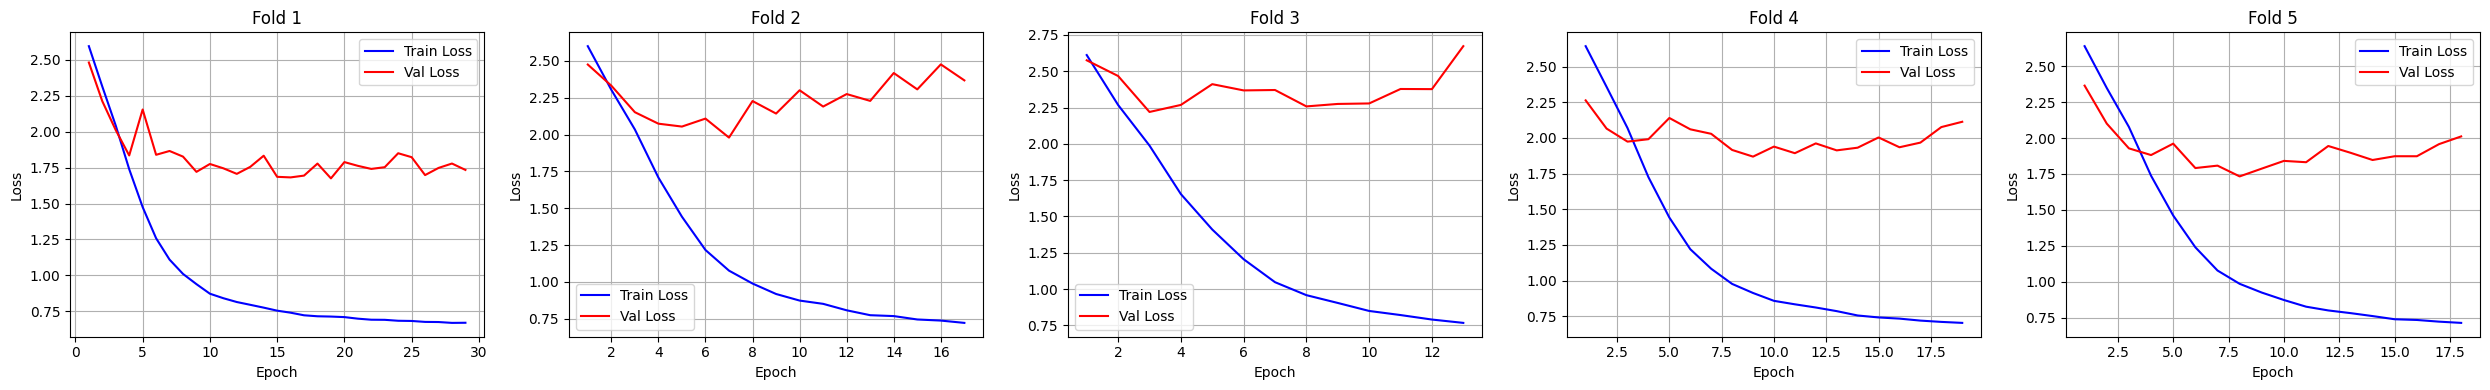

Saved training curves to C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\training_curves_all_folds.png


In [29]:
# ==================== Plot Training History for All Folds ====================

if 'cv_results' in dir() and cv_results is not None:
    fig, axes = plt.subplots(1, len(cv_results['fold_histories']), figsize=(5 * len(cv_results['fold_histories']), 4))
    
    if len(cv_results['fold_histories']) == 1:
        axes = [axes]
    
    for fold_idx, (ax, history) in enumerate(zip(axes, cv_results['fold_histories'])):
        epochs = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
        ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'Fold {fold_idx + 1}')
        ax.legend()
        ax.grid(True)
    
    plt.tight_layout()
    plt.savefig(config.OUTPUT_DIR / 'training_curves_all_folds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved training curves to {config.OUTPUT_DIR / 'training_curves_all_folds.png'}")

In [30]:
# ==================== Detailed Evaluation with Best Models ====================

@torch.no_grad()
def evaluate_fold(fold_idx: int, val_idx: np.ndarray, config: Config, device: torch.device):
    """
    Load best model for a fold and run detailed evaluation.
    
    Returns predictions, labels, and probabilities for all tasks.
    """
    # Load model with config.DROPOUT
    model = ROPMultiTaskModel(
        model_name=config.MODEL_NAME, 
        pretrained=False,
        dropout=config.DROPOUT
    )
    checkpoint_path = config.OUTPUT_DIR / f"fold_{fold_idx + 1}" / "best_model.pt"
    
    if not checkpoint_path.exists():
        print(f"Checkpoint not found: {checkpoint_path}")
        return None
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"  Best epoch: {checkpoint['epoch']}, Val loss: {checkpoint['val_loss']:.4f}")
    
    # Create validation dataset
    val_df = dataset_df.iloc[val_idx].reset_index(drop=True)
    val_dataset = ROPDataset(val_df, transforms=get_valid_transforms(config.IMG_SIZE))
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Collect predictions
    all_preds = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
    all_labels = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
    all_probs = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
    all_paths = []
    
    for batch in tqdm(val_loader, desc=f"Evaluating Fold {fold_idx + 1}"):
        images = batch['image'].to(device)
        labels = batch['labels']
        paths = batch['image_path']
        
        outputs = model(images)
        
        for task_name, output in outputs.items():
            probs = F.softmax(output, dim=1).cpu().numpy()
            preds = output.argmax(dim=1).cpu().numpy()
            
            all_probs[task_name].extend(probs)
            all_preds[task_name].extend(preds)
            all_labels[task_name].extend(labels[task_name].numpy())
        
        all_paths.extend(paths)
    
    return {
        'preds': all_preds,
        'labels': all_labels,
        'probs': all_probs,
        'paths': all_paths,
        'val_df': val_df
    }

# Run evaluation for all folds
fold_evaluations = []
for fold_idx, (train_idx, val_idx) in enumerate(cv_splits):
    result = evaluate_fold(fold_idx, val_idx, config, device)
    if result is not None:
        fold_evaluations.append(result)

print(f"\nEvaluated {len(fold_evaluations)} folds")

Backbone: efficientnet_b0, features: 1280
Loaded model from C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\fold_1\best_model.pt
  Best epoch: 19, Val loss: 1.6752


Evaluating Fold 1:   0%|          | 0/107 [00:00<?, ?it/s]

Backbone: efficientnet_b0, features: 1280
Loaded model from C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\fold_2\best_model.pt
  Best epoch: 7, Val loss: 1.9799


Evaluating Fold 2:   0%|          | 0/106 [00:00<?, ?it/s]

Backbone: efficientnet_b0, features: 1280
Loaded model from C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\fold_3\best_model.pt
  Best epoch: 3, Val loss: 2.2197


...

Backbone: efficientnet_b0, features: 1280
Loaded model from C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\fold_4\best_model.pt
  Best epoch: 9, Val loss: 1.8686


Evaluating Fold 4:   0%|          | 0/106 [00:00<?, ?it/s]

Backbone: efficientnet_b0, features: 1280
Loaded model from C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\fold_5\best_model.pt
  Best epoch: 8, Val loss: 1.7327


Evaluating Fold 5:   0%|          | 0/108 [00:00<?, ?it/s]


Evaluated 5 folds


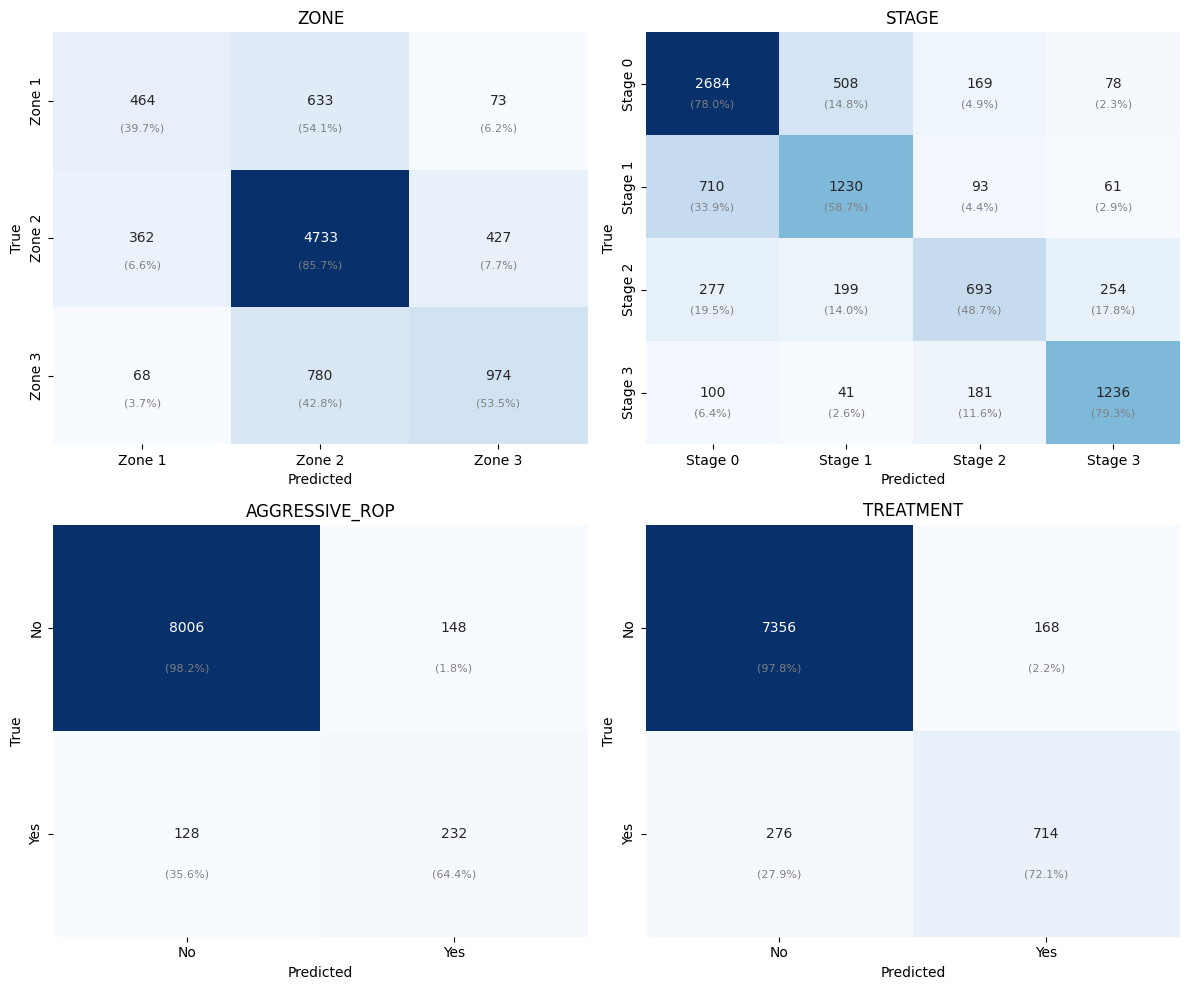

Saved confusion matrices to C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\confusion_matrices.png


In [20]:
# ==================== Aggregate Results and Plot Confusion Matrices ====================

# Aggregate predictions from all folds
aggregated_preds = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
aggregated_labels = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
aggregated_probs = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}

for fold_eval in fold_evaluations:
    for task in ROPMultiTaskModel.TASK_CONFIG.keys():
        aggregated_preds[task].extend(fold_eval['preds'][task])
        aggregated_labels[task].extend(fold_eval['labels'][task])
        aggregated_probs[task].extend(fold_eval['probs'][task])

# Plot confusion matrices for all tasks (excluding plus which has no valid labels)
tasks_to_plot = ['zone', 'stage', 'aggressive_rop', 'treatment']
label_names = {
    'zone': ['Zone 1', 'Zone 2', 'Zone 3'],
    'stage': ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3'],
    'aggressive_rop': ['No', 'Yes'],
    'treatment': ['No', 'Yes']
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, task_name in zip(axes, tasks_to_plot):
    preds = np.array(aggregated_preds[task_name])
    labels = np.array(aggregated_labels[task_name])
    
    # Filter valid labels
    valid_mask = labels >= 0
    preds = preds[valid_mask]
    labels = labels[valid_mask]
    
    if len(labels) == 0:
        ax.set_title(f'{task_name.upper()} - No valid labels')
        continue
    
    cm = confusion_matrix(labels, preds)
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=ax, cbar=False,
        xticklabels=label_names.get(task_name, range(cm.shape[1])),
        yticklabels=label_names.get(task_name, range(cm.shape[0]))
    )
    
    # Add percentage annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.7, f'({cm_normalized[i, j]:.1%})',
                   ha='center', va='center', fontsize=8, color='gray')
    
    ax.set_title(f'{task_name.upper()}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved confusion matrices to {config.OUTPUT_DIR / 'confusion_matrices.png'}")

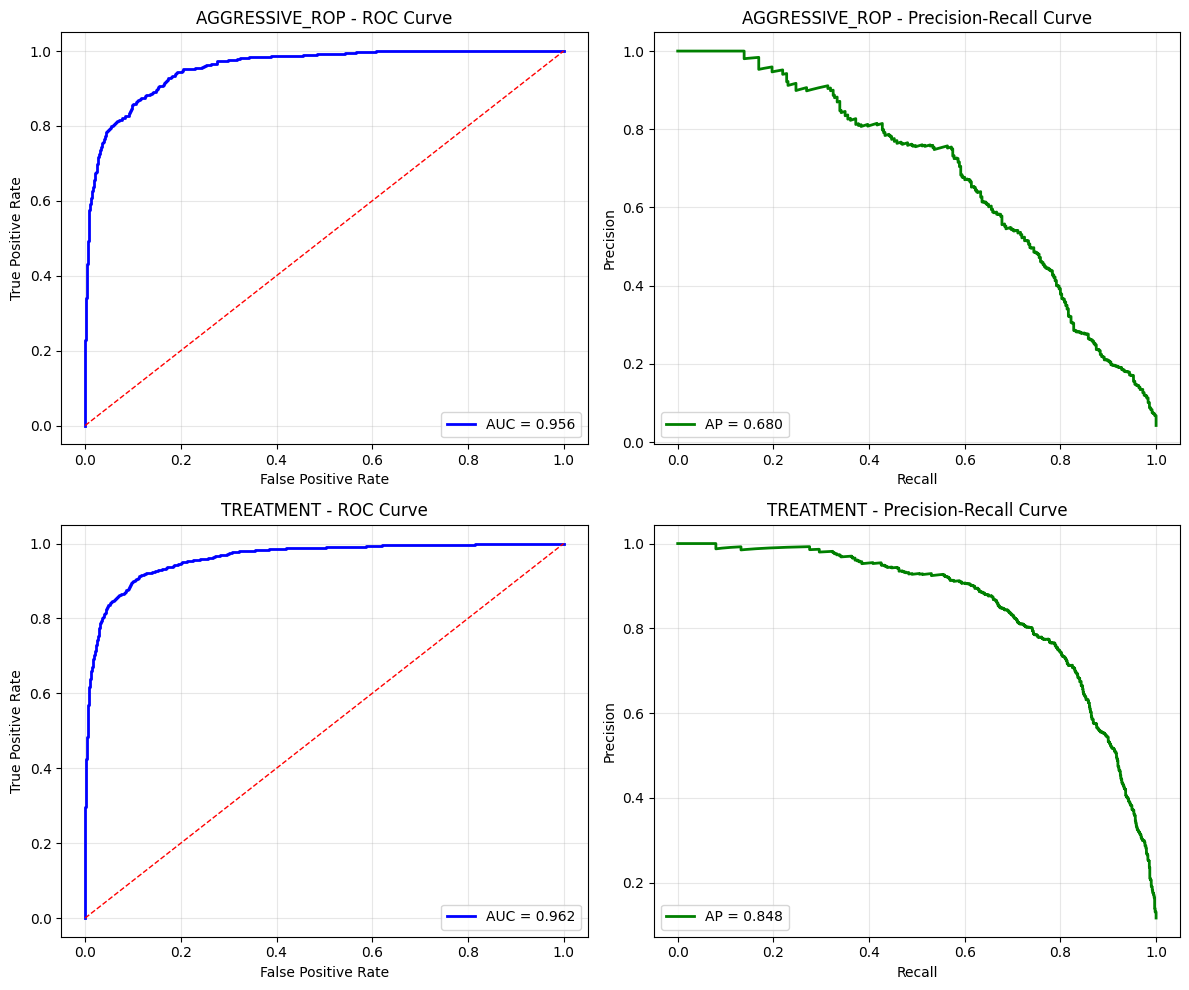

Saved ROC/PR curves to C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\roc_pr_curves.png


In [21]:
# ==================== ROC Curves for Binary Tasks ====================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

binary_tasks = ['aggressive_rop', 'treatment']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, task_name in enumerate(binary_tasks):
    labels = np.array(aggregated_labels[task_name])
    probs = np.array(aggregated_probs[task_name])
    
    # Filter valid labels
    valid_mask = labels >= 0
    labels = labels[valid_mask]
    probs = probs[valid_mask]
    
    if len(labels) == 0 or len(np.unique(labels)) < 2:
        continue
    
    # Get probability of positive class
    pos_probs = probs[:, 1]
    
    # ROC curve
    fpr, tpr, thresholds_roc = roc_curve(labels, pos_probs)
    roc_auc = auc(fpr, tpr)
    
    ax_roc = axes[idx, 0]
    ax_roc.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc:.3f}')
    ax_roc.plot([0, 1], [0, 1], 'r--', linewidth=1)
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'{task_name.upper()} - ROC Curve')
    ax_roc.legend(loc='lower right')
    ax_roc.grid(True, alpha=0.3)
    
    # Precision-Recall curve
    precision, recall, thresholds_pr = precision_recall_curve(labels, pos_probs)
    ap = average_precision_score(labels, pos_probs)
    
    ax_pr = axes[idx, 1]
    ax_pr.plot(recall, precision, 'g-', linewidth=2, label=f'AP = {ap:.3f}')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'{task_name.upper()} - Precision-Recall Curve')
    ax_pr.legend(loc='lower left')
    ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved ROC/PR curves to {config.OUTPUT_DIR / 'roc_pr_curves.png'}")

In [22]:
# ==================== Detailed Classification Report ====================

print("=" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 70)

for task_name in tasks_to_plot:
    preds = np.array(aggregated_preds[task_name])
    labels = np.array(aggregated_labels[task_name])
    
    # Filter valid labels
    valid_mask = labels >= 0
    preds = preds[valid_mask]
    labels = labels[valid_mask]
    
    if len(labels) == 0:
        continue
    
    print(f"\n{'='*50}")
    print(f"{task_name.upper()}")
    print('='*50)
    
    target_names = label_names.get(task_name, [str(i) for i in range(len(np.unique(labels)))])
    print(classification_report(labels, preds, target_names=target_names, digits=4))
    
    # Additional metrics
    accuracy = accuracy_score(labels, preds)
    print(f"Overall Accuracy: {accuracy:.4f}")
    
    if task_name in ['zone', 'stage']:
        qwk = quadratic_weighted_kappa(labels, preds)
        print(f"Quadratic Weighted Kappa: {qwk:.4f}")
    
    if task_name in binary_tasks:
        probs = np.array(aggregated_probs[task_name])[valid_mask]
        pos_probs = probs[:, 1]
        roc_auc = roc_auc_score(labels, pos_probs)
        print(f"AUC-ROC: {roc_auc:.4f}")

DETAILED CLASSIFICATION REPORT

ZONE
              precision    recall  f1-score   support

      Zone 1     0.5190    0.3966    0.4496      1170
      Zone 2     0.7701    0.8571    0.8113      5522
      Zone 3     0.6608    0.5346    0.5910      1822

    accuracy                         0.7248      8514
   macro avg     0.6500    0.5961    0.6173      8514
weighted avg     0.7122    0.7248    0.7144      8514

Overall Accuracy: 0.7248
Quadratic Weighted Kappa: 0.4753

STAGE
              precision    recall  f1-score   support

     Stage 0     0.7117    0.7805    0.7445      3439
     Stage 1     0.6218    0.5874    0.6041      2094
     Stage 2     0.6100    0.4870    0.5416      1423
     Stage 3     0.7587    0.7933    0.7757      1558

    accuracy                         0.6863      8514
   macro avg     0.6756    0.6620    0.6665      8514
weighted avg     0.6812    0.6863    0.6818      8514

Overall Accuracy: 0.6863
Quadratic Weighted Kappa: 0.7433

AGGRESSIVE_ROP
        

In [23]:
# ==================== Save Results to Excel ====================

# Create summary DataFrame
summary_data = []

for task_name in tasks_to_plot:
    preds = np.array(aggregated_preds[task_name])
    labels = np.array(aggregated_labels[task_name])
    
    valid_mask = labels >= 0
    preds = preds[valid_mask]
    labels = labels[valid_mask]
    
    if len(labels) == 0:
        continue
    
    row = {'Task': task_name.upper()}
    row['Accuracy'] = accuracy_score(labels, preds)
    row['N_samples'] = len(labels)
    
    if task_name in ['zone', 'stage']:
        row['QWK'] = quadratic_weighted_kappa(labels, preds)
    else:
        row['QWK'] = np.nan
    
    if task_name in binary_tasks:
        probs = np.array(aggregated_probs[task_name])[valid_mask]
        pos_probs = probs[:, 1]
        row['AUC-ROC'] = roc_auc_score(labels, pos_probs)
        row['AP'] = average_precision_score(labels, pos_probs)
        
        cm = confusion_matrix(labels, preds)
        tn, fp, fn, tp = cm.ravel()
        row['Sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0
        row['Specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        row['AUC-ROC'] = np.nan
        row['AP'] = np.nan
        row['Sensitivity'] = np.nan
        row['Specificity'] = np.nan
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
display(summary_df)

# Save to Excel
excel_path = config.OUTPUT_DIR / 'evaluation_results.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    # Save per-fold metrics
    fold_metrics_data = []
    for fold_idx, fold_metrics in enumerate(cv_results['fold_metrics']):
        if fold_metrics is None:
            continue
        for task_name, metrics in fold_metrics.items():
            row = {'Fold': fold_idx + 1, 'Task': task_name}
            row.update(metrics)
            fold_metrics_data.append(row)
    
    if fold_metrics_data:
        fold_df = pd.DataFrame(fold_metrics_data)
        fold_df.to_excel(writer, sheet_name='Per-Fold Metrics', index=False)

print(f"\nSaved results to {excel_path}")


SUMMARY TABLE


,Task,Accuracy,N_samples,QWK,AUC-ROC,AP,Sensitivity,Specificity
0,ZONE,0.724806,8514,0.475259,NaN,NaN,NaN,NaN
1,STAGE,0.686281,8514,0.743291,NaN,NaN,NaN,NaN
2,AGGRESSIVE_ROP,0.967583,8514,NaN,0.956075,0.679684,0.644444,0.981849
3,TREATMENT,0.947851,8514,NaN,0.961924,0.847957,0.721212,0.977671



Saved results to C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\evaluation_results.xlsx


In [24]:
# ==================== Save Per-Image Predictions ====================

# Combine all predictions with image paths
all_predictions = []

for fold_idx, fold_eval in enumerate(fold_evaluations):
    for i, path in enumerate(fold_eval['paths']):
        row = {
            'fold': fold_idx + 1,
            'image_path': path,
            'image_name': Path(path).name
        }
        
        for task_name in ROPMultiTaskModel.TASK_CONFIG.keys():
            row[f'{task_name}_pred'] = fold_eval['preds'][task_name][i]
            row[f'{task_name}_label'] = fold_eval['labels'][task_name][i]
            row[f'{task_name}_correct'] = fold_eval['preds'][task_name][i] == fold_eval['labels'][task_name][i]
            
            # Add probabilities for binary tasks
            if task_name in binary_tasks:
                row[f'{task_name}_prob'] = fold_eval['probs'][task_name][i][1]
        
        all_predictions.append(row)

predictions_df = pd.DataFrame(all_predictions)

# Save to CSV
predictions_path = config.OUTPUT_DIR / 'per_image_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)
print(f"Saved per-image predictions to {predictions_path}")

# Show misclassified samples summary
print("\n" + "=" * 70)
print("MISCLASSIFICATION SUMMARY")
print("=" * 70)

for task_name in tasks_to_plot:
    correct_col = f'{task_name}_correct'
    label_col = f'{task_name}_label'
    
    # Filter valid labels
    valid_df = predictions_df[predictions_df[label_col] >= 0]
    
    total = len(valid_df)
    correct = valid_df[correct_col].sum()
    incorrect = total - correct
    
    print(f"\n{task_name.upper()}:")
    print(f"  Correct: {correct}/{total} ({100*correct/total:.1f}%)")
    print(f"  Incorrect: {incorrect}/{total} ({100*incorrect/total:.1f}%)")

print(f"\nResults saved to: {config.OUTPUT_DIR}")

Saved per-image predictions to C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2\per_image_predictions.csv

MISCLASSIFICATION SUMMARY

ZONE:
  Correct: 6171/8514 (72.5%)
  Incorrect: 2343/8514 (27.5%)

STAGE:
  Correct: 5843/8514 (68.6%)
  Incorrect: 2671/8514 (31.4%)

AGGRESSIVE_ROP:
  Correct: 8238/8514 (96.8%)
  Incorrect: 276/8514 (3.2%)

TREATMENT:
  Correct: 8070/8514 (94.8%)
  Incorrect: 444/8514 (5.2%)

Results saved to: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_v2
